# Лабараторная работа 1. CNN

### Распознование марки автомобиля по фотографии (Audi, BMW, Mercedes, Toyota)

In [1]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models
from torchvision.transforms import v2 as T2
from tqdm.auto import tqdm
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Андрей\ML\NeuralNetworksLabs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [3]:
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

In [4]:
DATA_DIR = "data"
BATCH_SIZE = 32

In [5]:
train_transforms = T2.Compose([
    T2.Resize((224,224)),
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomRotation(10),         
    T2.ColorJitter(0.1,0.1,0.1,0.05),
    T2.ToTensor(),
])

val_test_transforms = T2.Compose([
    T2.Resize((224,224)),
    T2.ToTensor(),
])

c:\Users\Андрей\ML\NeuralNetworksLabs\venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [6]:
import h5py
from PIL import Image
import numpy as np

temp_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
class_names = temp_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Classes: ['audi', 'bmw', 'mercedes-benz', 'toyota']
Number of classes: 4


In [7]:
def create_augmented_datasets_hdf5(data_dir, output_file="augmented_data.h5", num_augments=4):
    if os.path.exists(output_file):
        print(f"Файл {output_file} уже существует, пропускаем создание")
        return
    
    print(f"Создание аугментированного датасета в {output_file}...")
    
    with h5py.File(output_file, 'w') as f:
        for split in ['train', 'val', 'test']:
            print(f"\nОбработка {split} набора...")
            
            split_dir = os.path.join(data_dir, split)
            dataset = datasets.ImageFolder(split_dir)
            
            n_original = len(dataset)
            n_augments = num_augments if split == 'train' else 1
            n_total = n_original * n_augments
            
            grp = f.create_group(split)
            imgs_dset = grp.create_dataset('images', shape=(n_total, 224, 224, 3), dtype=np.uint8)
            labels_dset = grp.create_dataset('labels', shape=(n_total,), dtype=np.int32)
            
            idx = 0
            
            if split == 'train':
                transforms = train_transforms
            else:
                transforms = val_test_transforms
            
            for img_idx, (img_path, label) in enumerate(tqdm(dataset.samples, desc=f"{split}")):
                with Image.open(img_path) as img:
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    for aug_idx in range(n_augments):
                        augmented = transforms(img)
                        img_array = (augmented.numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
                        
                        imgs_dset[idx] = img_array
                        labels_dset[idx] = label
                        idx += 1
            
            print(f"{split}: сохранено {idx} изображений")
    
    print(f"\nАугментированные данные сохранены в {output_file}")

create_augmented_datasets_hdf5(DATA_DIR, "augmented_data.h5", num_augments=4)

Создание аугментированного датасета в augmented_data.h5...

Обработка train набора...


train: 100%|██████████| 2375/2375 [01:52<00:00, 21.03it/s]


train: сохранено 9500 изображений

Обработка val набора...


val: 100%|██████████| 509/509 [00:03<00:00, 143.78it/s]


val: сохранено 509 изображений

Обработка test набора...


test: 100%|██████████| 511/511 [00:04<00:00, 119.16it/s]

test: сохранено 511 изображений

Аугментированные данные сохранены в augmented_data.h5


In [8]:
class HDF5Dataset(torch.utils.data.Dataset):
    def __init__(self, h5_file, split='train'):
        self.h5_file = h5_file
        self.split = split
        
        with h5py.File(h5_file, 'r') as f:
            self.length = f[split]['images'].shape[0]
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        with h5py.File(self.h5_file, 'r') as f:
            img = f[self.split]['images'][idx]
            label = f[self.split]['labels'][idx]
        
        img = torch.from_numpy(img).float() / 255.0
        img = img.permute(2, 0, 1)
        
        img = T2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img)
        
        label = torch.tensor(label, dtype=torch.int64)
        
        return img, label

print("Загрузка данных из HDF5...")
train_dataset = HDF5Dataset("augmented_data.h5", split='train')
val_dataset = HDF5Dataset("augmented_data.h5", split='val')
test_dataset = HDF5Dataset("augmented_data.h5", split='test')

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Загрузка данных из HDF5...
Train samples: 9500
Val samples: 509
Test samples: 511


In [9]:
with h5py.File("augmented_data.h5", 'r') as f:
    targets = f['train']['labels'][:]

class_counts = Counter(targets)
num_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = [num_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: [0.6928238039673279, 0.753489847715736, 1.380813953488372, 1.9791666666666667]


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"DataLoaders созданы. Batch size: {BATCH_SIZE}")

DataLoaders созданы. Batch size: 32


In [11]:
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25, patience=5):
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        for phase in ["train","val"]:
            model.train() if phase=="train" else model.eval()
            loader = train_loader if phase=="train" else val_loader

            running_loss = 0.0
            running_corrects = 0
            loop = tqdm(loader, desc=phase, leave=False)

            for inputs, labels in loop:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    with autocast(device_type=device.type):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)

                    if phase=="train":
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)
                loop.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase=="val":
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        model.load_state_dict(best_model_wts)
                        print(f"Best Val Accuracy: {best_acc:.4f}")
                        return model, history

    model.load_state_dict(best_model_wts)
    print(f"\nBest Val Accuracy: {best_acc:.4f}")
    return model, history

##### Архитектура 1

In [12]:
class CNN_v1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [13]:
model1 = CNN_v1(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model1.parameters(), lr=0.001)

model1, history1 = train_model(model1, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=10)


Epoch [1/100]


train Loss: 1.3910 | Acc: 0.3026


val Loss: 1.3907 | Acc: 0.2790

Epoch [2/100]


train Loss: 1.3573 | Acc: 0.3284


val Loss: 1.3729 | Acc: 0.3379

Epoch [3/100]


...

val Loss: 1.2021 | Acc: 0.5462

Epoch [38/100]


train Loss: 0.5600 | Acc: 0.7672


val Loss: 1.1675 | Acc: 0.5560

Epoch [39/100]


train Loss: 0.5537 | Acc: 0.7685


val Loss: 1.1939 | Acc: 0.5422
Early stopping at epoch 39
Best Val Accuracy: 0.5678


##### Архитектура 2

In [14]:
class CNN_v2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [15]:
model2 = CNN_v2(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model2.parameters(), lr=0.001)

model2, history2 = train_model(model2, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=10)


Epoch [1/100]


train Loss: 1.4072 | Acc: 0.2914


val Loss: 1.4089 | Acc: 0.2849

Epoch [2/100]


train Loss: 1.3716 | Acc: 0.3128


val Loss: 1.3618 | Acc: 0.2338

Epoch [3/100]


...

val Loss: 0.7856 | Acc: 0.7701

Epoch [50/100]


train Loss: 0.1447 | Acc: 0.9412


val Loss: 0.7587 | Acc: 0.7642

Epoch [51/100]


train Loss: 0.1499 | Acc: 0.9405


val Loss: 0.7728 | Acc: 0.7682
Early stopping at epoch 51
Best Val Accuracy: 0.7760


##### Архитектура 3

In [16]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, max(channels // reduction, 1))
        self.fc2 = nn.Linear(max(channels // reduction, 1), channels)
    
    def forward(self, x):
        batch, channels, height, width = x.size()
        squeeze = x.mean((2, 3))
        excitation = torch.relu(self.fc1(squeeze))
        excitation = torch.sigmoid(self.fc2(excitation))
        excitation = excitation.view(batch, channels, 1, 1)
        return x * excitation

class CNN_v3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            SEBlock(32),
            nn.MaxPool2d(2),
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SEBlock(128),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [17]:
model3 = CNN_v3(num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model3.parameters(), lr=0.001)

model3, history3 = train_model(model3, criterion, optimizer, train_loader, val_loader, num_epochs=100, patience=10)


Epoch [1/100]


train:   0%|          | 0/297 [00:00<?, ?it/s]

train Loss: 1.4264 | Acc: 0.2697


val Loss: 1.3788 | Acc: 0.2672

Epoch [2/100]


train Loss: 1.3813 | Acc: 0.2998


...

val Loss: 0.6864 | Acc: 0.7701

Epoch [50/100]


train Loss: 0.2611 | Acc: 0.8875


val Loss: 0.6910 | Acc: 0.7800

Epoch [51/100]


train Loss: 0.2467 | Acc: 0.8939


val Loss: 0.6951 | Acc: 0.7780
Early stopping at epoch 51
Best Val Accuracy: 0.7839


##### Transfer Learning (ResNet18)

In [18]:
model_tl = models.resnet50(weights="IMAGENET1K_V1")

for param in model_tl.layer1.parameters():
    param.requires_grad = False
for param in model_tl.layer2.parameters():
    param.requires_grad = False

num_features = model_tl.fc.in_features
model_tl.fc = nn.Linear(num_features, num_classes)

model_tl = model_tl.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model_tl.parameters(), lr=0.0001)

model_tl, history_tl = train_model(model_tl, criterion, optimizer, train_loader, val_loader, num_epochs=15, patience=5)


Epoch [1/15]


train Loss: 0.2957 | Acc: 0.8871


val Loss: 0.1961 | Acc: 0.9312

Epoch [2/15]


train Loss: 0.0290 | Acc: 0.9914


val Loss: 0.1917 | Acc: 0.9312

Epoch [3/15]


...

val Loss: 0.1850 | Acc: 0.9528

Epoch [14/15]


train Loss: 0.0004 | Acc: 1.0000


val Loss: 0.1764 | Acc: 0.9568

Epoch [15/15]


train Loss: 0.0006 | Acc: 0.9998


val Loss: 0.1703 | Acc: 0.9587

Best Val Accuracy: 0.9587


In [19]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(f"{title} Loss")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["val_acc"], label="val")
    plt.title(f"{title} Accuracy")
    plt.legend()
    
    plt.show()

In [20]:
def evaluate_on_test(model, model_name="Model"):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n{model_name} Test Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    return accuracy

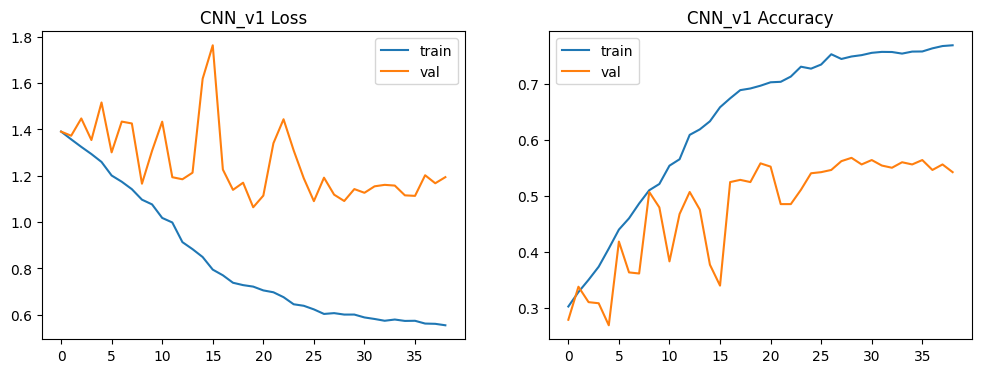

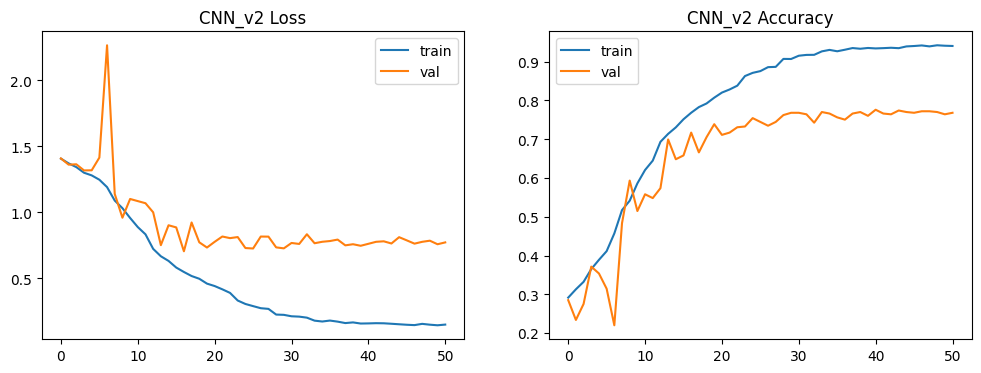

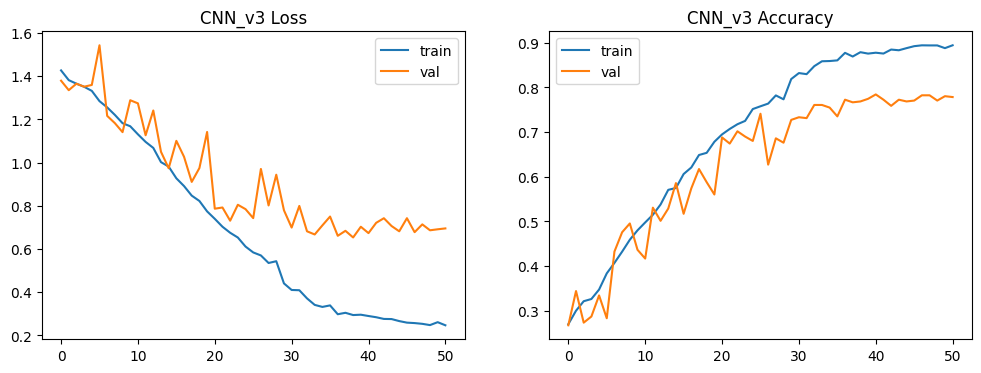

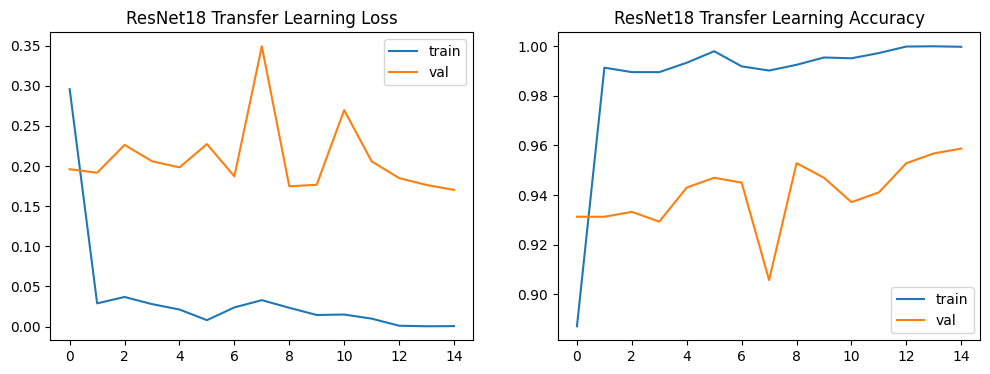

In [21]:
plot_history(history1, "CNN_v1")
plot_history(history2, "CNN_v2")
plot_history(history3, "CNN_v3")
plot_history(history_tl, "ResNet18 Transfer Learning")


CNN_v1 Test Accuracy: 0.6008

Classification Report:

               precision    recall  f1-score   support

         audi       0.72      0.66      0.69       184
          bmw       0.68      0.61      0.64       169
mercedes-benz       0.43      0.54      0.48        93
       toyota       0.43      0.51      0.47        65

     accuracy                           0.60       511
    macro avg       0.57      0.58      0.57       511
 weighted avg       0.62      0.60      0.61       511



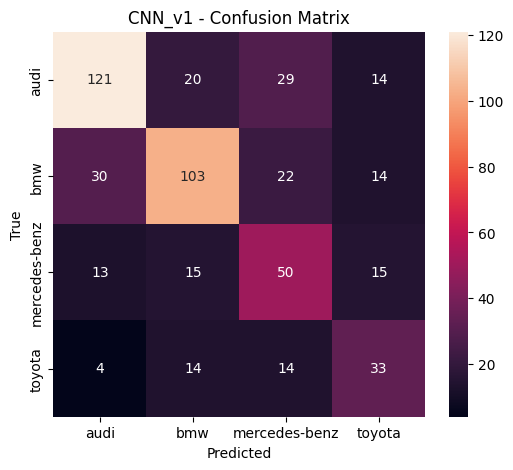


CNN_v2 Test Accuracy: 0.7632

Classification Report:

               precision    recall  f1-score   support

         audi       0.85      0.84      0.84       184
          bmw       0.75      0.76      0.76       169
mercedes-benz       0.72      0.68      0.70        93
       toyota       0.64      0.68      0.66        65

     accuracy                           0.76       511
    macro avg       0.74      0.74      0.74       511
 weighted avg       0.76      0.76      0.76       511



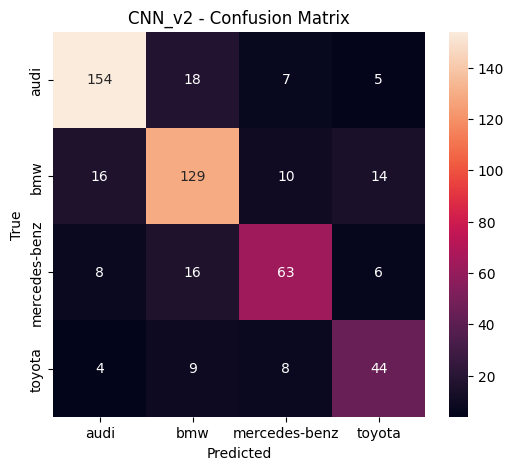


CNN_v3 Test Accuracy: 0.7965

Classification Report:

               precision    recall  f1-score   support

         audi       0.82      0.83      0.82       184
          bmw       0.83      0.81      0.82       169
mercedes-benz       0.69      0.73      0.71        93
       toyota       0.80      0.75      0.78        65

     accuracy                           0.80       511
    macro avg       0.79      0.78      0.78       511
 weighted avg       0.80      0.80      0.80       511



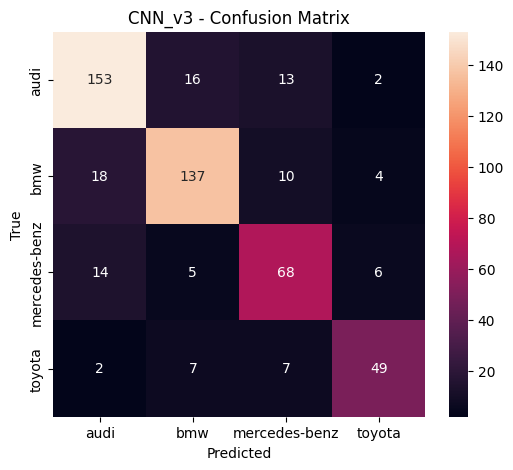


ResNet18 TL Test Accuracy: 0.9609

Classification Report:

               precision    recall  f1-score   support

         audi       0.98      0.97      0.97       184
          bmw       0.96      0.99      0.97       169
mercedes-benz       0.93      0.92      0.93        93
       toyota       0.95      0.92      0.94        65

     accuracy                           0.96       511
    macro avg       0.96      0.95      0.95       511
 weighted avg       0.96      0.96      0.96       511



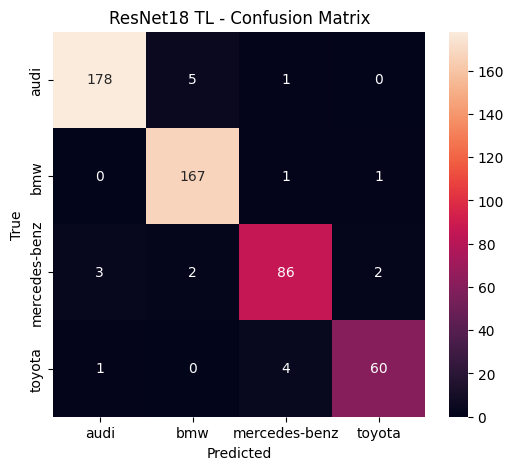

In [22]:
acc1 = evaluate_on_test(model1, "CNN_v1")
acc2 = evaluate_on_test(model2, "CNN_v2")
acc3 = evaluate_on_test(model3, "CNN_v3")
acc_tl = evaluate_on_test(model_tl, "ResNet18 TL")

In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "CNN_v1",
        "CNN_v2",
        "CNN_v3",
        "ResNet18 TL"
    ],
    "Test Accuracy": [
        acc1,
        acc2,
        acc3,
        acc_tl
    ]
})

results.sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy
3,ResNet18 TL,0.960861
2,CNN_v3,0.796477
1,CNN_v2,0.763209
0,CNN_v1,0.600783
